In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from pathlib import Path
import pandas as pd
import json
from src.config import CHECKPOINT_DIR, DEFAULT_TRAINING_PARAMS_V2, DEFAULT_TRAINING_PARAMS_V3, DEFAULT_STGCN_PARAMS_V1
from pathlib import Path
import matplotlib.pyplot as plt



In [6]:
# cnn_lstm
experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_6_Freeze_batchnorm"
experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_5_unfreeze_from_15"
experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_8"


default_config = DEFAULT_TRAINING_PARAMS_V3

In [37]:
# stgcn
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "grid_search_6"

default_config = DEFAULT_STGCN_PARAMS_V1

In [7]:
grid_search_results_path = experiment_root / "grid_search_results.csv"

df = pd.read_csv(grid_search_results_path)
df = df.sort_values("best_val_acc", ascending=False)
df.head(50)

,run_name,seed,num_frames,augment,batch_size,input_mode,learning_rate,cnn_learning_rate,min_lr,cnn_min_lr,...,cnn_cutoff,cnn_unfreeze_from,freeze_cnn_batchnorm,augmentation_params,best_val_acc,final_train_acc,final_val_acc,final_train_loss,final_val_loss,epochs_ran
0,baseline_best,42,32,True,4,diff,0.0001,0.000001,0.00001,1.000000e-07,...,19,15,True,"{'flip_prob': 0.5, 'brightness_range': (0.8, 1...",0.8650,0.961250,0.8375,0.276907,0.465521,21
5,hidden64_drop04,42,32,True,4,diff,0.0001,0.000001,0.00001,1.000000e-07,...,19,15,True,"{'flip_prob': 0.5, 'brightness_range': (0.8, 1...",0.8650,0.980625,0.8625,0.257480,0.466430,30
4,dropout_045,42,32,True,4,diff,0.0001,0.000001,0.00001,1.000000e-07,...,19,15,True,"{'flip_prob': 0.5, 'brightness_range': (0.8, 1...",0.8650,0.958750,0.8425,0.286298,0.459627,21
1,classifier_64,42,32,True,4,diff,0.0001,0.000001,0.00001,1.000000e-07,...,19,15,True,"{'flip_prob': 0.5, 'brightness_range': (0.8, 1...",0.8625,0.950625,0.8325,0.289806,0.464976,20
2,classifier_32,42,32,True,4,diff,0.0001,0.000001,0.00001,1.000000e-07,...,19,15,True,"{'flip_prob': 0.5, 'brightness_range': (0.8, 1...",0.8600,0.966875,0.8475,0.274498,0.457763,25
3,dropout_040,42,32,True,4,diff,0.0001,0.000001,0.00001,1.000000e-07,...,19,15,True,"{'flip_prob': 0.5, 'brightness_range': (0.8, 1...",0.8600,0.957500,0.8425,0.286736,0.455657,20
6,hidden64_drop045,42,32,True,4,diff,0.0001,0.000001,0.00001,1.000000e-07,...,19,15,True,"{'flip_prob': 0.5, 'brightness_range': (0.8, 1...",0.8550,0.950000,0.8425,0.298377,0.463544,20


In [8]:
def make_title(run_name, config, default_config=DEFAULT_TRAINING_PARAMS_V3):
    title = [run_name]

    for param in config:
        if param in default_config and config[param] != default_config[param]:
            title.append(f"{param}={config[param]}")

    return " | ".join(title)

def get_results(results_path):

    checkpoint_path = results_path / "best_model.pt"
    history_path = results_path / "history.csv"
    summary_path = results_path / "summary.csv"
    config_path = results_path / "config.json"

    required_files = [
        checkpoint_path,
        history_path,
        summary_path,
        config_path,
    ]

    if not all(path.exists() for path in required_files):
        return None

    checkpoint = torch.load(
        checkpoint_path,
        map_location=torch.device("cpu")
    )

    history = pd.read_csv(history_path)
    summary = pd.read_csv(summary_path)

    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)

    return checkpoint, history, summary, config

def plot_grid_search_results(experiment_root, default_config):

    run_dirs = sorted([d for d in experiment_root.iterdir() if d.is_dir()])
    
    for run_dir in run_dirs:

        results = get_results(run_dir)

        if results is None:
            print(f"Skipping incomplete run: {run_dir.name}")
            continue

        checkpoint, history, summary, config = results

        epochs = range(1, len(history["train_loss"]) + 1)

        title = make_title(run_dir.name, config, default_config=default_config)

        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history["train_loss"], label="Train Loss")
        plt.plot(epochs, history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history["train_acc"], label="Train Acc")
        plt.plot(epochs, history["val_acc"], label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

        print(summary['best_val_acc'][0])
        print(config)

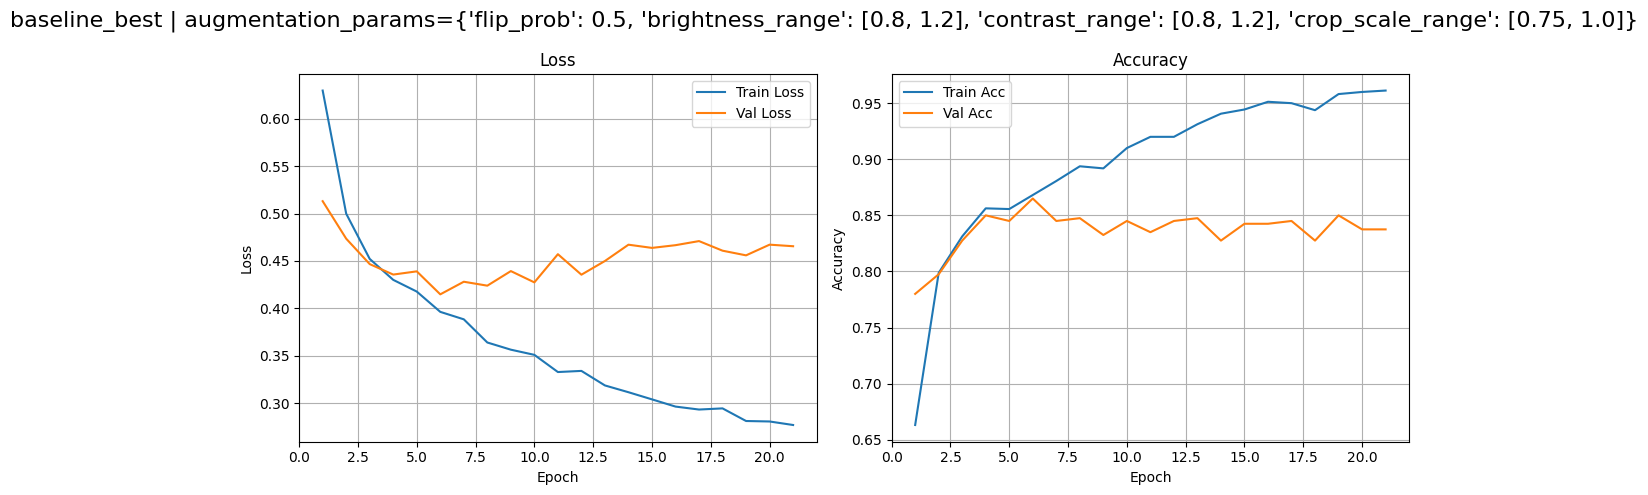

0.865
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 4, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15, 'freeze_cnn_batchnorm': True, 'augmentation_params': {'flip_prob': 0.5, 'brightness_range': [0.8, 1.2], 'contrast_range': [0.8, 1.2], 'crop_scale_range': [0.75, 1.0]}}


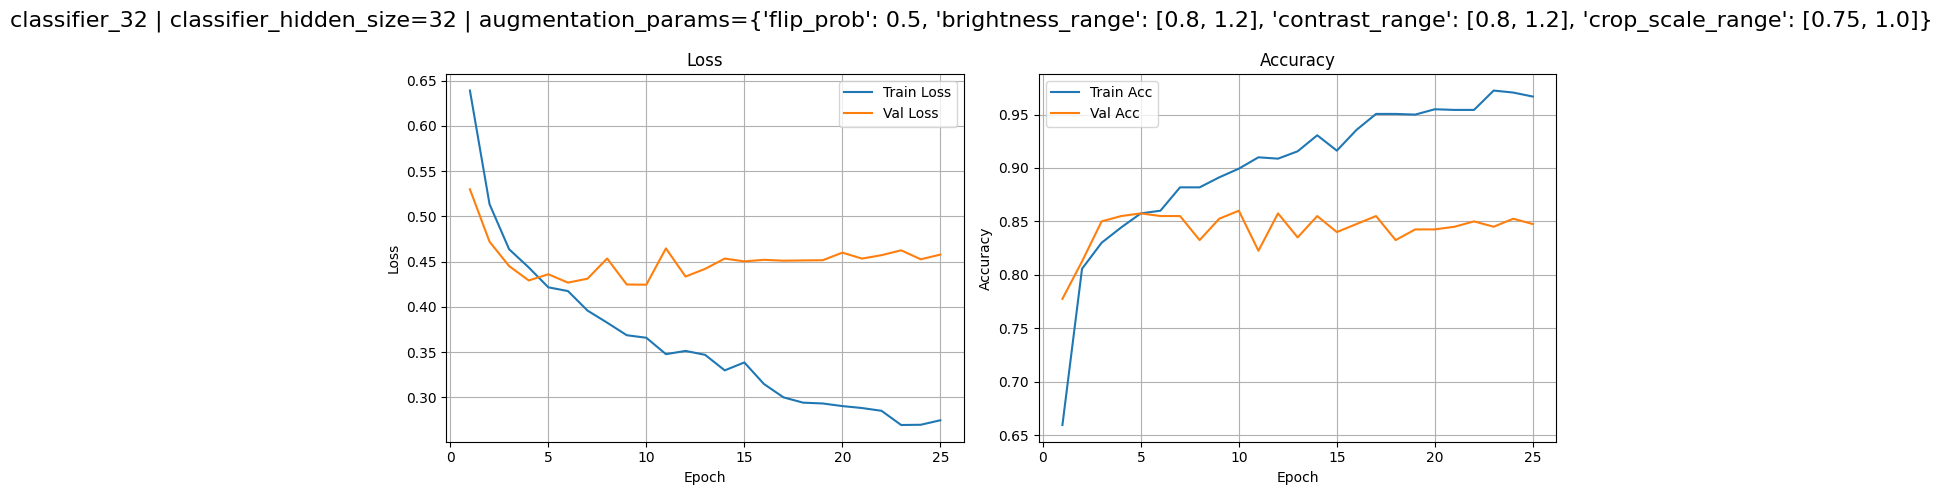

0.86
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 4, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 32, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15, 'freeze_cnn_batchnorm': True, 'augmentation_params': {'flip_prob': 0.5, 'brightness_range': [0.8, 1.2], 'contrast_range': [0.8, 1.2], 'crop_scale_range': [0.75, 1.0]}}


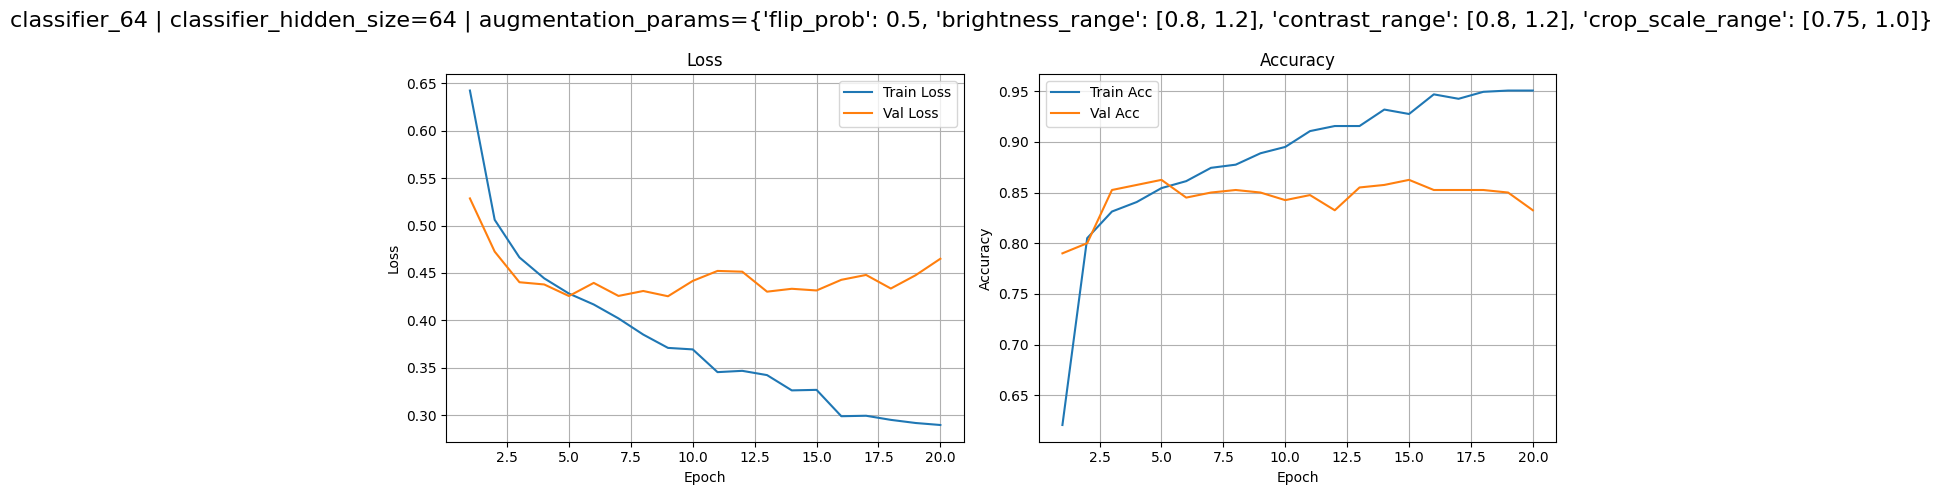

0.8625
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 4, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 64, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15, 'freeze_cnn_batchnorm': True, 'augmentation_params': {'flip_prob': 0.5, 'brightness_range': [0.8, 1.2], 'contrast_range': [0.8, 1.2], 'crop_scale_range': [0.75, 1.0]}}


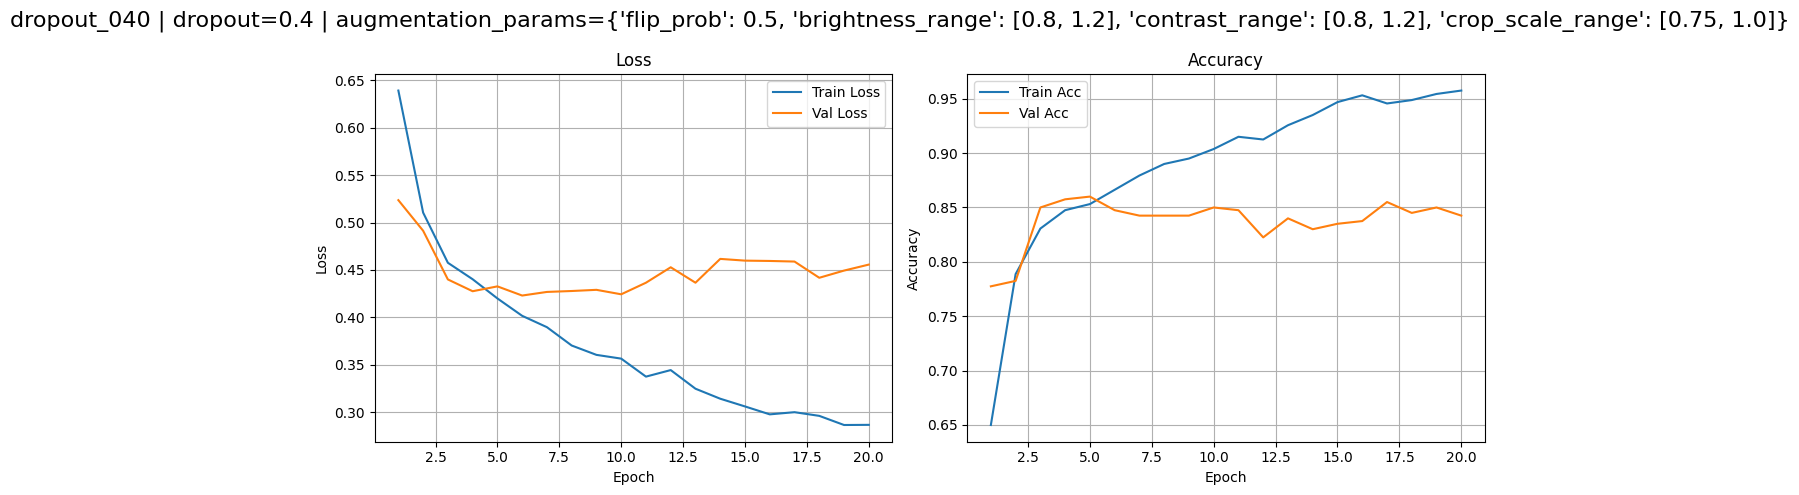

0.86
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 4, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.4, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15, 'freeze_cnn_batchnorm': True, 'augmentation_params': {'flip_prob': 0.5, 'brightness_range': [0.8, 1.2], 'contrast_range': [0.8, 1.2], 'crop_scale_range': [0.75, 1.0]}}


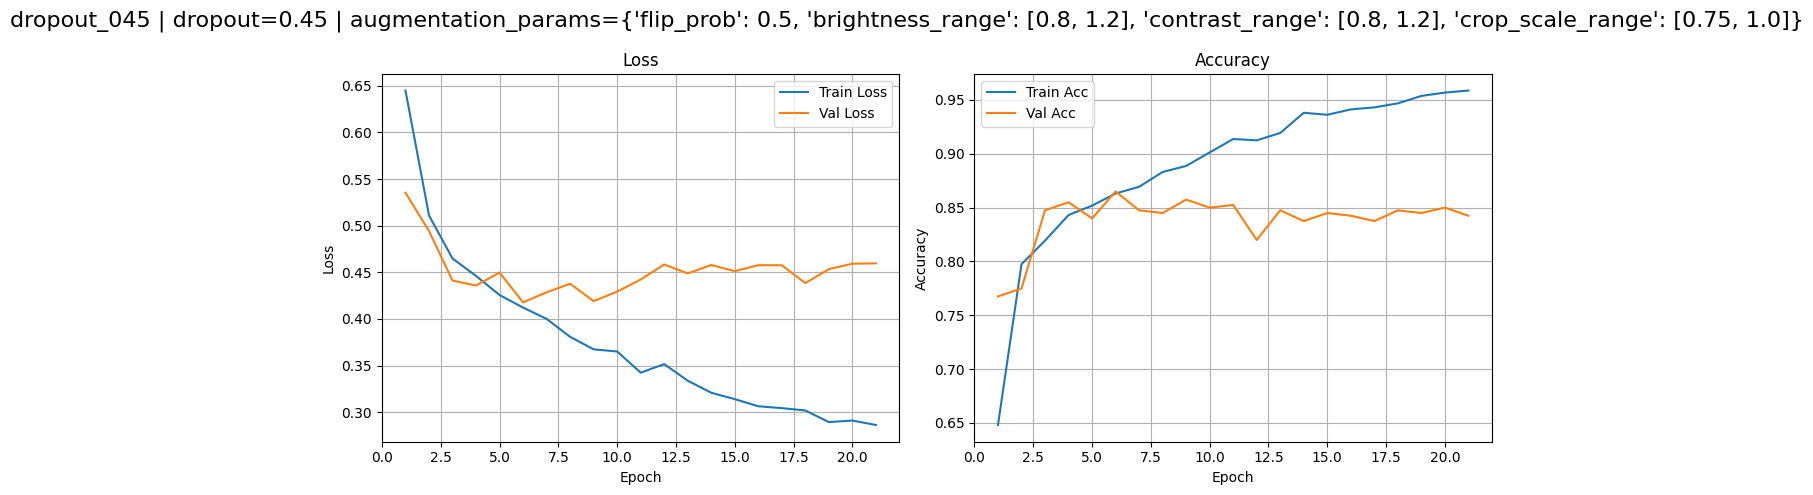

0.865
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 4, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 128, 'dropout': 0.45, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15, 'freeze_cnn_batchnorm': True, 'augmentation_params': {'flip_prob': 0.5, 'brightness_range': [0.8, 1.2], 'contrast_range': [0.8, 1.2], 'crop_scale_range': [0.75, 1.0]}}


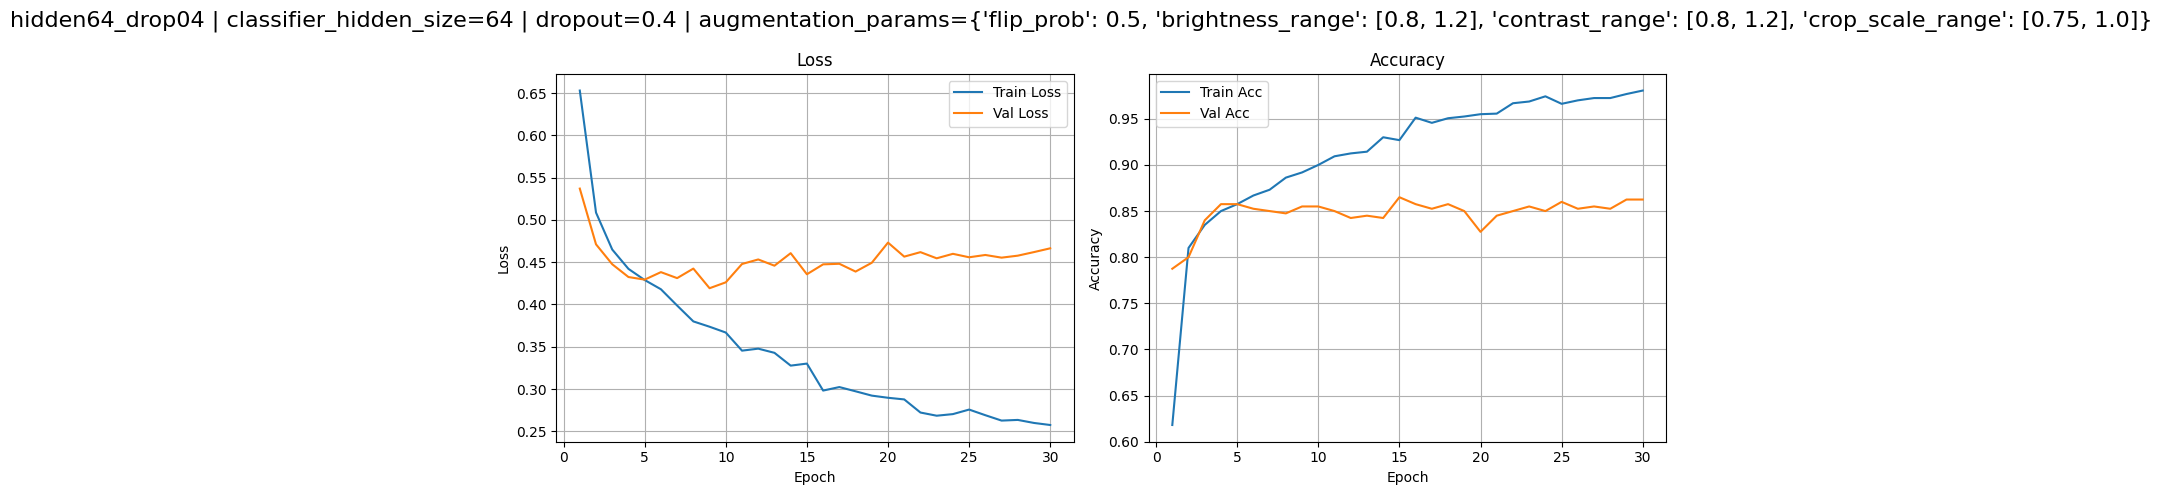

0.865
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 4, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 64, 'dropout': 0.4, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15, 'freeze_cnn_batchnorm': True, 'augmentation_params': {'flip_prob': 0.5, 'brightness_range': [0.8, 1.2], 'contrast_range': [0.8, 1.2], 'crop_scale_range': [0.75, 1.0]}}


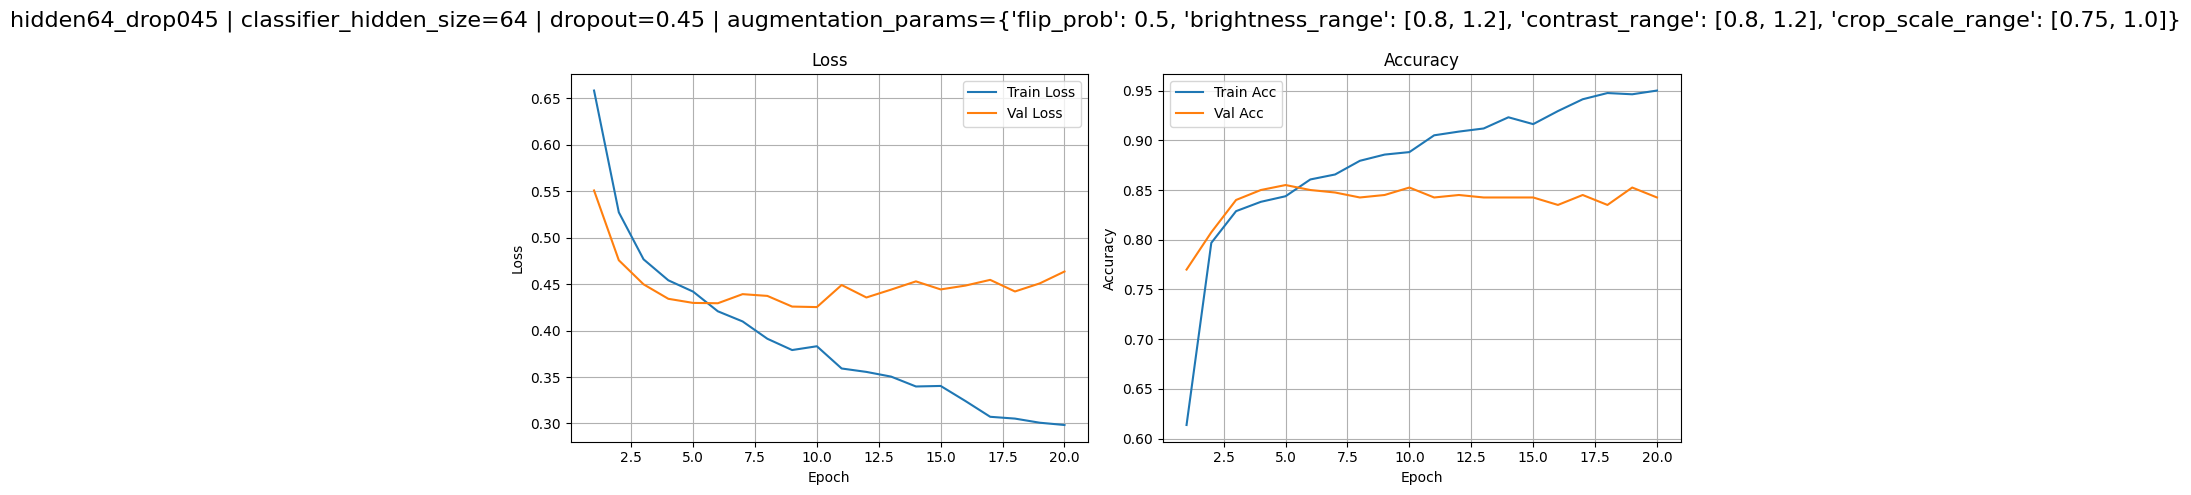

0.855
{'seed': 42, 'num_frames': 32, 'augment': True, 'batch_size': 4, 'input_mode': 'diff', 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-06, 'min_lr': 1e-05, 'cnn_min_lr': 1e-07, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'weight_decay': 5e-06, 'amsgrad': False, 'label_smoothing': 0.1, 'hidden_channels': 64, 'reduced_channels': 96, 'classifier_hidden_size': 64, 'dropout': 0.45, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15, 'freeze_cnn_batchnorm': True, 'augmentation_params': {'flip_prob': 0.5, 'brightness_range': [0.8, 1.2], 'contrast_range': [0.8, 1.2], 'crop_scale_range': [0.75, 1.0]}}


In [9]:

plot_grid_search_results(experiment_root, default_config=default_config)

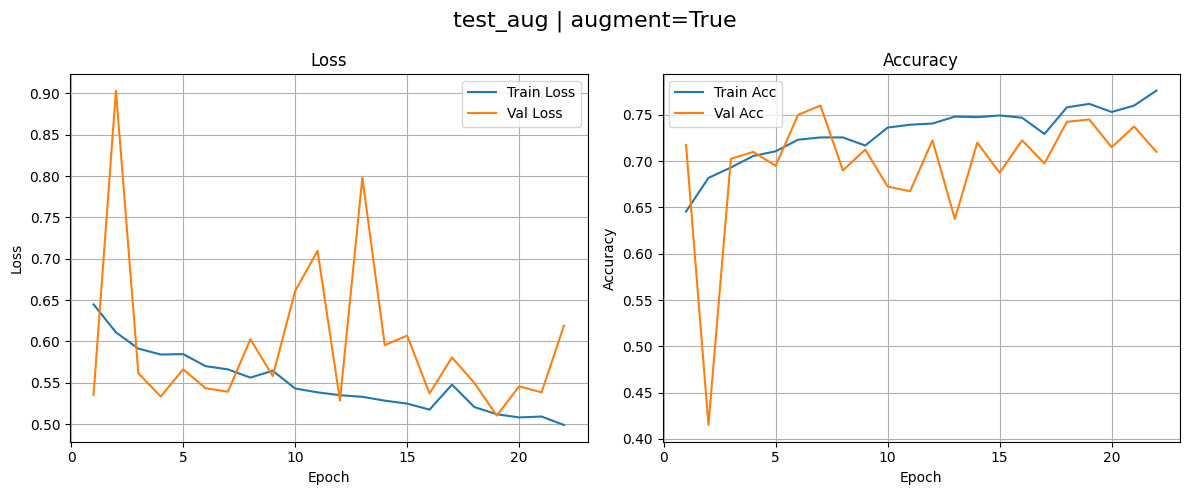

0.76
{'seed': 42, 'max_people': 4, 'batch_size': 4, 'augment': True, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'label_smoothing': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


In [6]:
# stgcn
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "test_aug"
default_config = DEFAULT_STGCN_PARAMS_V1

plot_grid_search_results(experiment_root, default_config=default_config)